
## NIO initial Points Density maps


In [4]:

# ============================================================
# Lorenz NIO Visual Discovery Paper
#
# Step 1 : Load NIO Results
# Step 2 : Summary Statistics
# Step 3 : 3D State Space Plot
# Step 4 : Projection Plots
# Step 5 : Sensitivity Density Maps
#
# Assumes:
#   nio_tumor_max.csv
#   nio_tumor_min.csv
#
# Uses:
#   300-step horizon only
#
# Ricardo Calix
# ============================================================


In [5]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import gaussian_kde


In [6]:

# ============================================================
# CONFIGURATION
# ============================================================

## MAX_FILE = "nio_tumor_max.csv"
## MIN_FILE = "nio_tumor_min.csv"

MAX_FILE = "nio_tumor_max.csv"


###########################################

random_flag = True        ## Change Only this


if random_flag:
    MIN_FILE    = "random_points.csv"
    name_output = "Random"
else:
    MIN_FILE    = "nio_tumor_min.csv"
    name_output = "Min"


###########################################

HORIZON = 300


In [7]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)


In [8]:

max_df


,Time_steps,point_id,T0,I0,C0
0,300,0,94.363075,1.008301,1.012808
1,300,1,94.355000,1.008443,1.015140
2,300,2,94.338260,1.008205,1.011293
3,300,3,94.363480,1.008082,1.019414
4,300,4,94.337350,1.007756,1.022836
...,...,...,...,...,...
3995,1300,995,1.002036,1.002354,1.008119
3996,1300,996,1.002685,1.002980,1.001838
3997,1300,997,1.002261,1.003928,1.004407
3998,1300,998,1.001121,1.008635,1.005036


In [9]:

min_df


,Time_steps,T0,I0,C0
0,300,85.984423,22.079260,19.091260
1,300,44.721803,33.004663,35.546521
2,300,65.122649,35.806584,94.944136
3,300,43.463470,26.167895,2.783258
4,300,22.728541,49.398432,49.169935
...,...,...,...,...
995,300,95.125649,89.218951,49.898464
996,300,75.891468,90.197186,48.406420
997,300,17.371417,64.712733,59.457261
998,300,87.880144,24.199604,44.319515


In [10]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [11]:

time_col


'Time_steps'

In [12]:

max_data = max_df[max_df[time_col] == HORIZON].copy()



In [13]:

if random_flag == False:
    min_data = min_df[min_df[time_col] == HORIZON].copy()
else:
    min_data = min_df.copy()    




In [14]:

max_data


,Time_steps,point_id,T0,I0,C0
0,300,0,94.363075,1.008301,1.012808
1,300,1,94.355000,1.008443,1.015140
2,300,2,94.338260,1.008205,1.011293
3,300,3,94.363480,1.008082,1.019414
4,300,4,94.337350,1.007756,1.022836
...,...,...,...,...,...
995,300,995,94.360620,1.007956,1.017016
996,300,996,94.380450,1.008049,1.001357
997,300,997,94.355540,1.008237,1.005542
998,300,998,94.348720,1.008216,1.016559


In [15]:

min_data


,Time_steps,T0,I0,C0
0,300,85.984423,22.079260,19.091260
1,300,44.721803,33.004663,35.546521
2,300,65.122649,35.806584,94.944136
3,300,43.463470,26.167895,2.783258
4,300,22.728541,49.398432,49.169935
...,...,...,...,...
995,300,95.125649,89.218951,49.898464
996,300,75.891468,90.197186,48.406420
997,300,17.371417,64.712733,59.457261
998,300,87.880144,24.199604,44.319515


In [16]:

print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 1000
Min-sensitive points : 1000




## SUMMARY STATISTICS


In [17]:

print("\n")
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)




SUMMARY STATISTICS


In [18]:

def summarize(df, label):

    stats = pd.DataFrame({
        "Mean": df[["T0","I0","C0"]].mean(),
        "Std":  df[["T0","I0","C0"]].std(),
        "Min":  df[["T0","I0","C0"]].min(),
        "Max":  df[["T0","I0","C0"]].max()
    })

    print("\n")
    print(label)
    print("-"*50)
    print(stats)


In [19]:

summarize(max_data, "MAX-SENSITIVE")




MAX-SENSITIVE
--------------------------------------------------
         Mean       Std       Min        Max
T0  94.364704  0.017472  94.15167  94.472290
I0   1.007952  0.000651   1.00307   1.008974
C0   1.014000  0.011290   1.00031   1.068353


In [20]:

summarize(min_data, "MIN-SENSITIVE")




MIN-SENSITIVE
--------------------------------------------------
         Mean        Std       Min        Max
T0  51.874882  28.557884  1.040701  99.989377
I0  50.710241  28.195292  1.103755  99.911821
C0  51.554219  28.613158  1.082604  99.874714




## 3D STATE SPACE


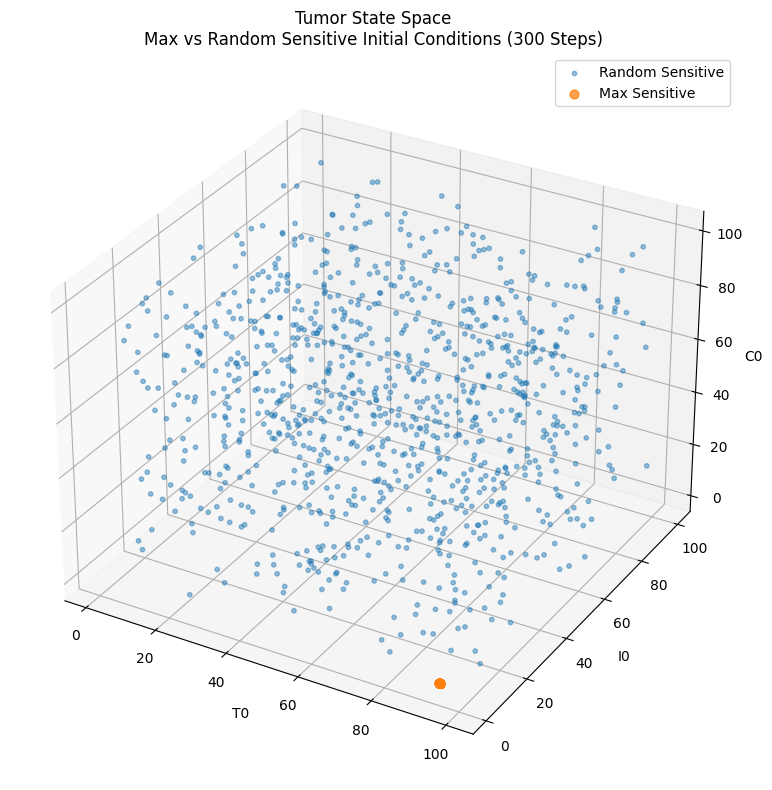

In [21]:

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)


ax.scatter(
    min_data["T0"],
    min_data["I0"],
    min_data["C0"],
    s=10,
    alpha=0.45,
    label=name_output + " Sensitive"
)

ax.scatter(
    max_data["T0"],
    max_data["I0"],
    max_data["C0"],
    s=40,
    alpha=0.75,
    label="Max Sensitive"
)

ax.set_xlabel("T0")
ax.set_ylabel("I0")
ax.set_zlabel("C0")

ax.set_title(
    f"Tumor State Space\nMax vs " + name_output + " Sensitive Initial Conditions (300 Steps)"
)

ax.legend()

plt.tight_layout()
plt.savefig(
    name_output + "_Figure1_3D_StateSpace.png",
    dpi=300
)

plt.show()





## PROJECTION PLOTS


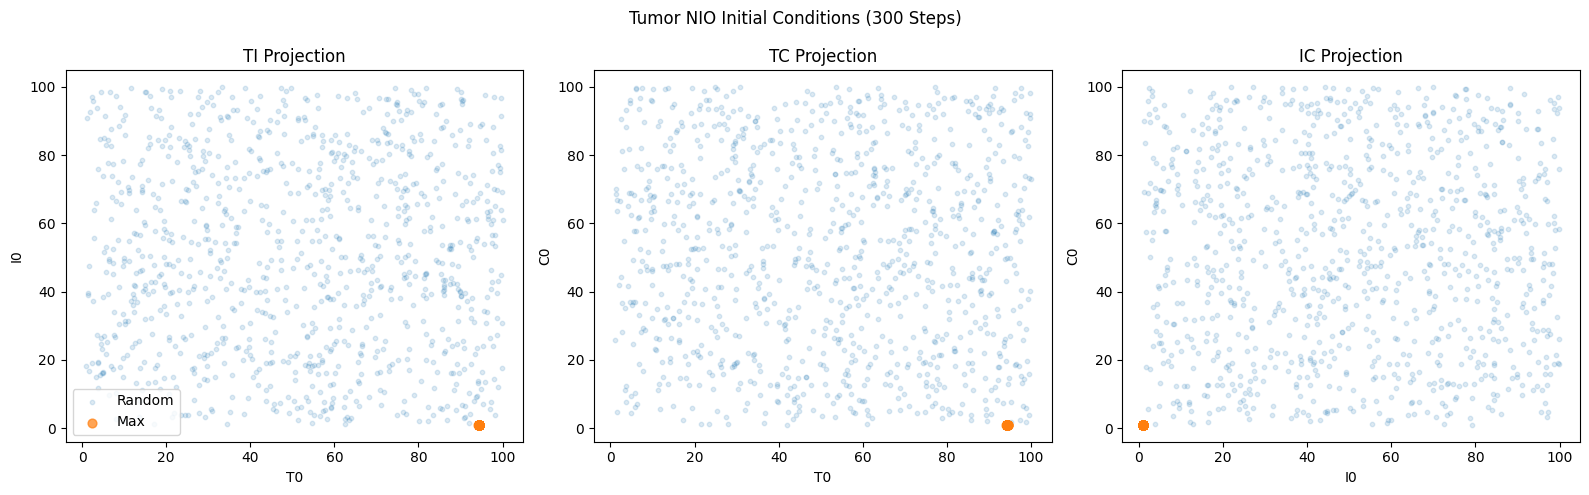

In [22]:


fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


# ------------------------------------------------------------
# XY
# ------------------------------------------------------------

axs[0].scatter(
    min_data["T0"],
    min_data["I0"],
    s=10,
    alpha=0.15,
    label=name_output + ""
)

axs[0].scatter(
    max_data["T0"],
    max_data["I0"],
    s=40,
    alpha=0.7,
    label="Max"
)

axs[0].set_title("TI Projection")
axs[0].set_xlabel("T0")
axs[0].set_ylabel("I0")

# ------------------------------------------------------------
# TC
# ------------------------------------------------------------

axs[1].scatter(
    min_data["T0"],
    min_data["C0"],
    s=10,
    alpha=0.15
)

axs[1].scatter(
    max_data["T0"],
    max_data["C0"],
    s=40,
    alpha=0.7
)

axs[1].set_title("TC Projection")
axs[1].set_xlabel("T0")
axs[1].set_ylabel("C0")

# ------------------------------------------------------------
# IC
# ------------------------------------------------------------

axs[2].scatter(
    min_data["I0"],
    min_data["C0"],
    s=10,
    alpha=0.15
)

axs[2].scatter(
    max_data["I0"],
    max_data["C0"],
    s=40,
    alpha=0.7
)

axs[2].set_title("IC Projection")
axs[2].set_xlabel("I0")
axs[2].set_ylabel("C0")


axs[0].legend()

plt.suptitle(
    f"Tumor NIO Initial Conditions ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure2_ProjectionPlots.png",
    dpi=300
)

plt.show()




## SENSITIVITY DENSITY MAPS

* rho_max - rho_min



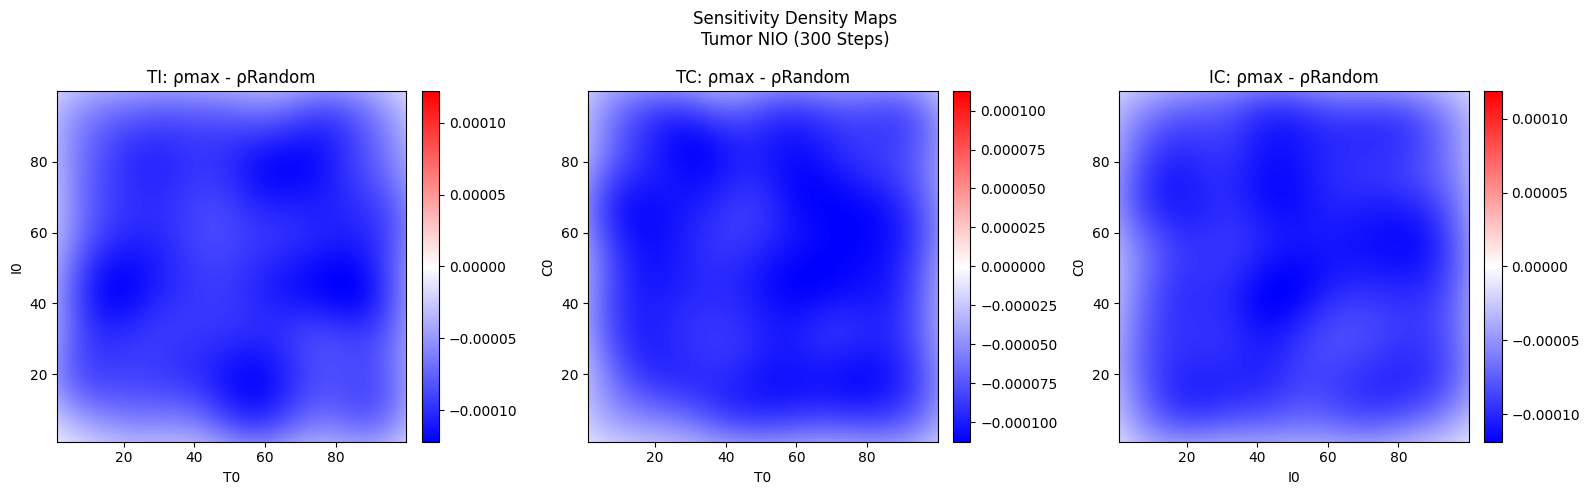

In [23]:

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


pairs = [
    ("T0","I0","TI"),
    ("T0","C0","TC"),
    ("I0","C0","IC")
]


for ax, (a,b,title) in zip(axs,pairs):

    all_a = np.concatenate([
        max_data[a],
        min_data[a]
    ])

    all_b = np.concatenate([
        max_data[b],
        min_data[b]
    ])

    grid_a = np.linspace(
        all_a.min(),
        all_a.max(),
        120
    )

    grid_b = np.linspace(
        all_b.min(),
        all_b.max(),
        120
    )

    A,B = np.meshgrid(
        grid_a,
        grid_b
    )

    kde_max = gaussian_kde(
        np.vstack([
            max_data[a],
            max_data[b]
        ])
    )

    kde_min = gaussian_kde(
        np.vstack([
            min_data[a],
            min_data[b]
        ])
    )

    rho_max = kde_max(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    rho_min = kde_min(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    density_difference = (
        rho_max - rho_min
    )

    vmax = np.abs(
        density_difference
    ).max()

    image = ax.imshow(
        density_difference,
        origin="lower",
        extent=[
            grid_a.min(),
            grid_a.max(),
            grid_b.min(),
            grid_b.max()
        ],
        aspect="auto",
        cmap="bwr",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_title(
        f"{title}: ρmax - ρ" + name_output
    )

    ax.set_xlabel(a)
    ax.set_ylabel(b)

    plt.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

 
plt.suptitle(
    f"Sensitivity Density Maps\nTumor NIO ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure3_DensityMaps.png",
    dpi=300
)

plt.show()




## Broken up approach of the previous 




## CREATE XY GRID

* We first create a common coordinate system that both populations will use


In [24]:



x_max = max_data["T0"]
y_max = max_data["I0"]

x_min = min_data["T0"]
y_min = min_data["I0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_y = np.linspace(ymin, ymax, 120)

X_xy, Y_xy = np.meshgrid(
    grid_x,
    grid_y
)


In [25]:

grid_x


array([ 1.04070124,  1.87220272,  2.70370419,  3.53520566,  4.36670714,
        5.19820861,  6.02971009,  6.86121156,  7.69271303,  8.52421451,
        9.35571598, 10.18721746, 11.01871893, 11.85022041, 12.68172188,
       13.51322335, 14.34472483, 15.1762263 , 16.00772778, 16.83922925,
       17.67073072, 18.5022322 , 19.33373367, 20.16523515, 20.99673662,
       21.8282381 , 22.65973957, 23.49124104, 24.32274252, 25.15424399,
       25.98574547, 26.81724694, 27.64874841, 28.48024989, 29.31175136,
       30.14325284, 30.97475431, 31.80625579, 32.63775726, 33.46925873,
       34.30076021, 35.13226168, 35.96376316, 36.79526463, 37.6267661 ,
       38.45826758, 39.28976905, 40.12127053, 40.952772  , 41.78427347,
       42.61577495, 43.44727642, 44.2787779 , 45.11027937, 45.94178085,
       46.77328232, 47.60478379, 48.43628527, 49.26778674, 50.09928822,
       50.93078969, 51.76229116, 52.59379264, 53.42529411, 54.25679559,
       55.08829706, 55.91979854, 56.75130001, 57.58280148, 58.41

In [26]:

grid_y


array([ 1.0030704 ,  1.83423637,  2.66540234,  3.49656832,  4.32773429,
        5.15890026,  5.99006623,  6.8212322 ,  7.65239818,  8.48356415,
        9.31473012, 10.14589609, 10.97706206, 11.80822804, 12.63939401,
       13.47055998, 14.30172595, 15.13289192, 15.9640579 , 16.79522387,
       17.62638984, 18.45755581, 19.28872178, 20.11988775, 20.95105373,
       21.7822197 , 22.61338567, 23.44455164, 24.27571761, 25.10688359,
       25.93804956, 26.76921553, 27.6003815 , 28.43154747, 29.26271345,
       30.09387942, 30.92504539, 31.75621136, 32.58737733, 33.41854331,
       34.24970928, 35.08087525, 35.91204122, 36.74320719, 37.57437317,
       38.40553914, 39.23670511, 40.06787108, 40.89903705, 41.73020303,
       42.561369  , 43.39253497, 44.22370094, 45.05486691, 45.88603289,
       46.71719886, 47.54836483, 48.3795308 , 49.21069677, 50.04186275,
       50.87302872, 51.70419469, 52.53536066, 53.36652663, 54.1976926 ,
       55.02885858, 55.86002455, 56.69119052, 57.52235649, 58.35


## KDE for Max-Sensitive Points


In [27]:



kde_max_xy = gaussian_kde(
    np.vstack([
        x_max,
        y_max
    ])
)

rho_max_xy = kde_max_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [28]:

kde_max_xy


In [29]:

rho_max_xy


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])


## KDE for Min-Sensitive Points


In [30]:



kde_min_xy = gaussian_kde(
    np.vstack([
        x_min,
        y_min
    ])
)

rho_min_xy = kde_min_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [31]:

# ==================================================
# 
# DIFFERENCE MAP
# ==================================================

rho_diff_xy = (
    rho_max_xy - rho_min_xy
)


In [32]:

rho_diff_xy


array([[-1.50056415e-05, -1.62556259e-05, -1.75198009e-05, ...,
        -3.40157240e-05, -3.18035638e-05, -2.95540820e-05],
       [-1.66710939e-05, -1.80319290e-05, -1.94041228e-05, ...,
        -3.65195415e-05, -3.41555986e-05, -3.17499554e-05],
       [-1.84458594e-05, -1.99212768e-05, -2.14044584e-05, ...,
        -3.89793843e-05, -3.64676303e-05, -3.39097147e-05],
       ...,
       [-2.86076128e-05, -3.05242005e-05, -3.24058588e-05, ...,
        -2.97450431e-05, -2.76752411e-05, -2.56356403e-05],
       [-2.69989477e-05, -2.88049123e-05, -3.05777267e-05, ...,
        -2.79247742e-05, -2.59723699e-05, -2.40495680e-05],
       [-2.53404020e-05, -2.70339286e-05, -2.86963170e-05, ...,
        -2.60779500e-05, -2.42466173e-05, -2.24440164e-05]])

In [33]:

# ==================================================

# XZ PROJECTION
# ==================================================

x_max = max_data["T0"]
z_max = max_data["C0"]

x_min = min_data["T0"]
z_min = min_data["C0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_z = np.linspace(zmin, zmax, 120)

X_xz, Z_xz = np.meshgrid(
    grid_x,
    grid_z
)

kde_max_xz = gaussian_kde(
    np.vstack([
        x_max,
        z_max
    ])
)

rho_max_xz = kde_max_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

kde_min_xz = gaussian_kde(
    np.vstack([
        x_min,
        z_min
    ])
)

rho_min_xz = kde_min_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

rho_diff_xz = (
    rho_max_xz -
    rho_min_xz
)


In [34]:

# ==================================================
# YZ PROJECTION
# ==================================================

y_max = max_data["I0"]
z_max = max_data["C0"]

y_min = min_data["I0"]
z_min = min_data["C0"]

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_y = np.linspace(ymin, ymax, 120)
grid_z = np.linspace(zmin, zmax, 120)

Y_yz, Z_yz = np.meshgrid(
    grid_y,
    grid_z
)

kde_max_yz = gaussian_kde(
    np.vstack([
        y_max,
        z_max
    ])
)

rho_max_yz = kde_max_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

kde_min_yz = gaussian_kde(
    np.vstack([
        y_min,
        z_min
    ])
)

rho_min_yz = kde_min_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

rho_diff_yz = (
    rho_max_yz -
    rho_min_yz
)


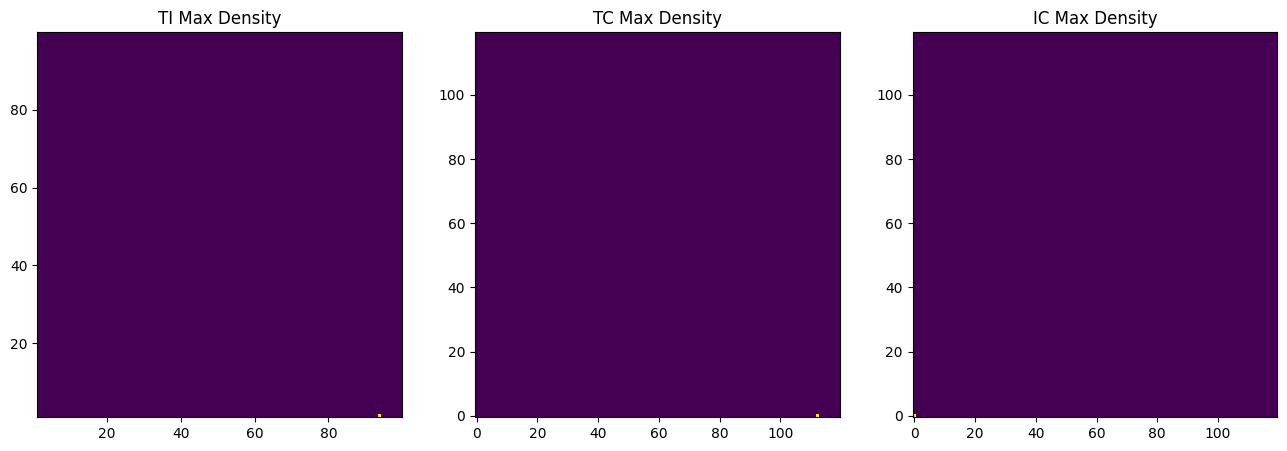

In [35]:

## Where does NIO find highly sensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_max_xy,
    origin="lower",
    extent=[
        grid_x.min(),
        grid_x.max(),
        grid_y.min(),
        grid_y.max()
    ],
    aspect="auto"
)

axs[0].set_title("TI Max Density")

axs[1].imshow(
    rho_max_xz,
    origin="lower",
    aspect="auto"
)

axs[1].set_title("TC Max Density")

axs[2].imshow(
    rho_max_yz,
    origin="lower",
    aspect="auto"
)

axs[2].set_title("IC Max Density")

plt.show()


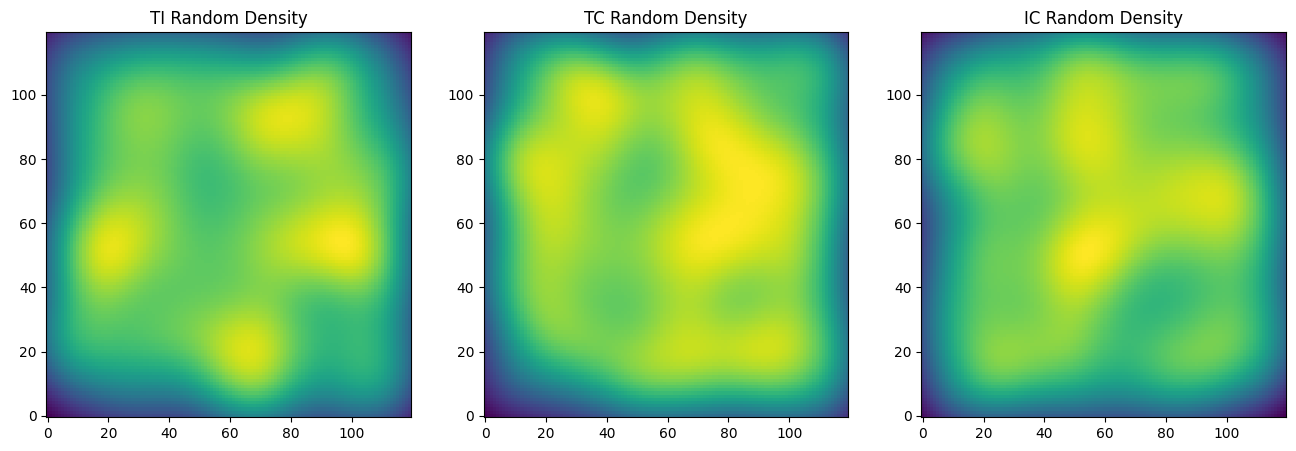

In [36]:

## Where does NIO find insensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(rho_min_xy,origin="lower",aspect="auto")
axs[0].set_title("TI " + name_output + " Density")

axs[1].imshow(rho_min_xz,origin="lower",aspect="auto")
axs[1].set_title("TC " + name_output + " Density")

axs[2].imshow(rho_min_yz,origin="lower",aspect="auto")
axs[2].set_title("IC " + name_output + " Density")

plt.show()


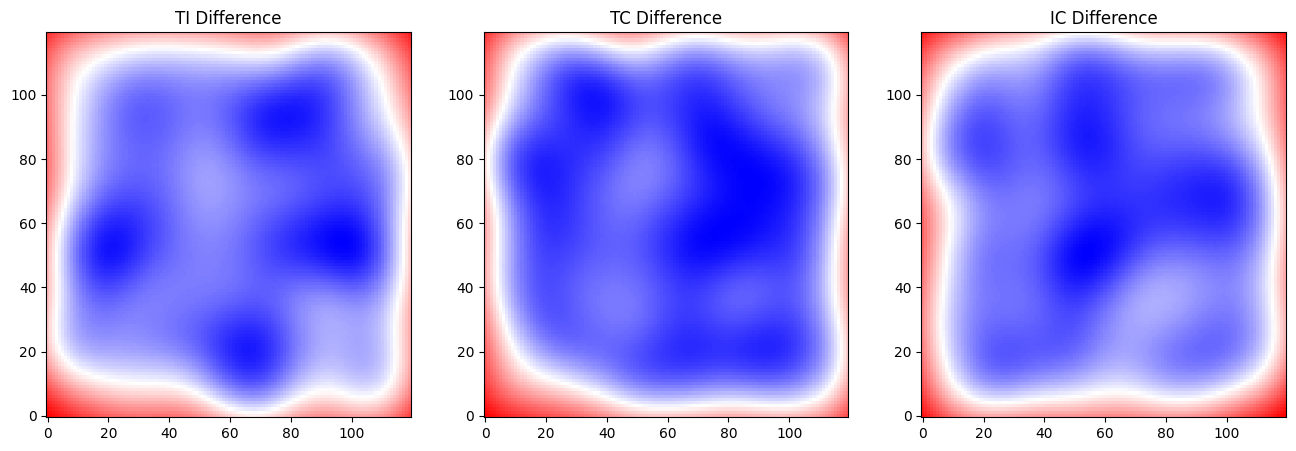

In [37]:

## Where do max-sensitive and min-sensitive regions differ?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_diff_xy,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[0].set_title("TI Difference")

axs[1].imshow(
    rho_diff_xz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[1].set_title("TC Difference")

axs[2].imshow(
    rho_diff_yz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[2].set_title("IC Difference")

plt.show()



## More simplification 


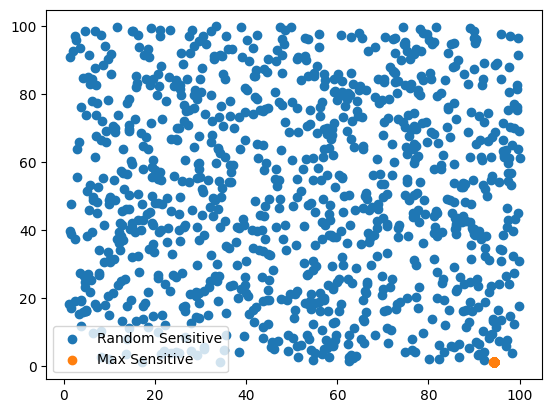

In [38]:


plt.scatter(
    min_data["T0"],
    min_data["I0"],
    label=name_output + " Sensitive"
)

plt.scatter(
    max_data["T0"],
    max_data["I0"],
    label="Max Sensitive"
)


plt.legend()
plt.show()


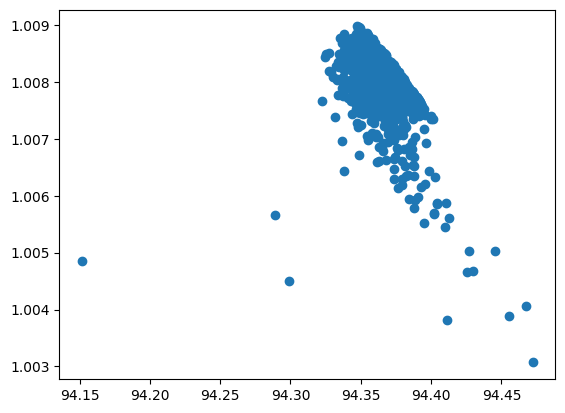

In [39]:

x = max_data["T0"]
y = max_data["I0"]

plt.scatter(x,y)
plt.show()


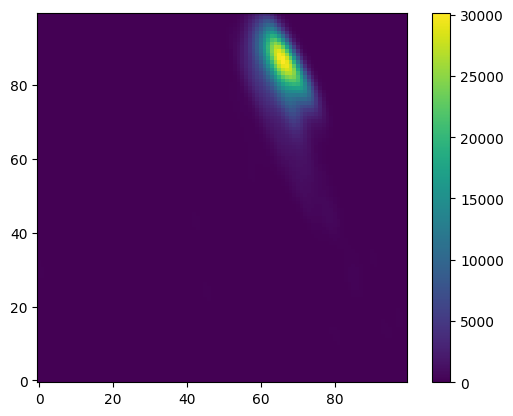

In [40]:

kde = gaussian_kde(
    np.vstack([x,y])
)

grid_x = np.linspace(x.min(),x.max(),100)
grid_y = np.linspace(y.min(),y.max(),100)

X,Y = np.meshgrid(
    grid_x,
    grid_y
)

rho = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
)

rho = rho.reshape(
    X.shape
)

plt.imshow(
    rho,
    origin="lower"
)

plt.colorbar()
plt.show()



## Super Simple Again


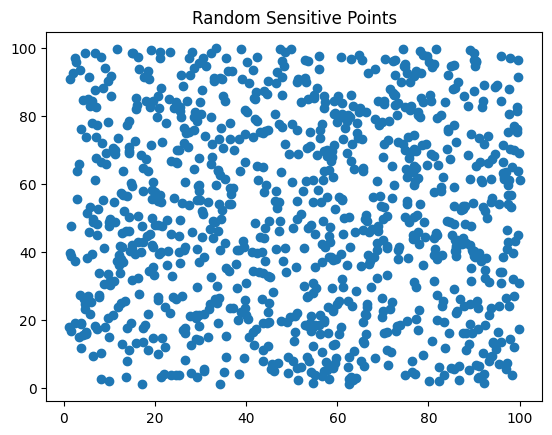

In [41]:

x = min_data["T0"]
y = min_data["I0"]

plt.scatter(x,y)
plt.title(name_output + " Sensitive Points")
plt.show()


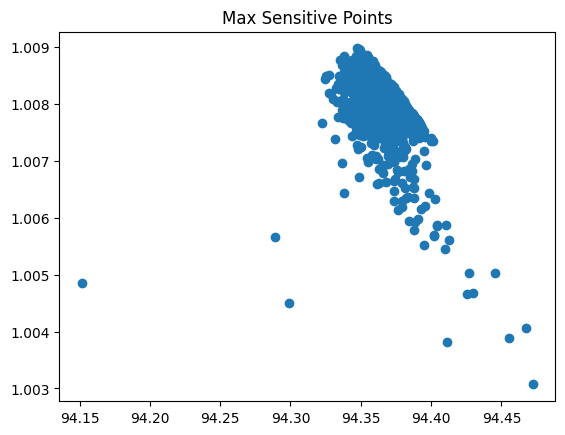

In [42]:

x = max_data["T0"]
y = max_data["I0"]

plt.scatter(x,y)
plt.title("Max Sensitive Points")
plt.show()


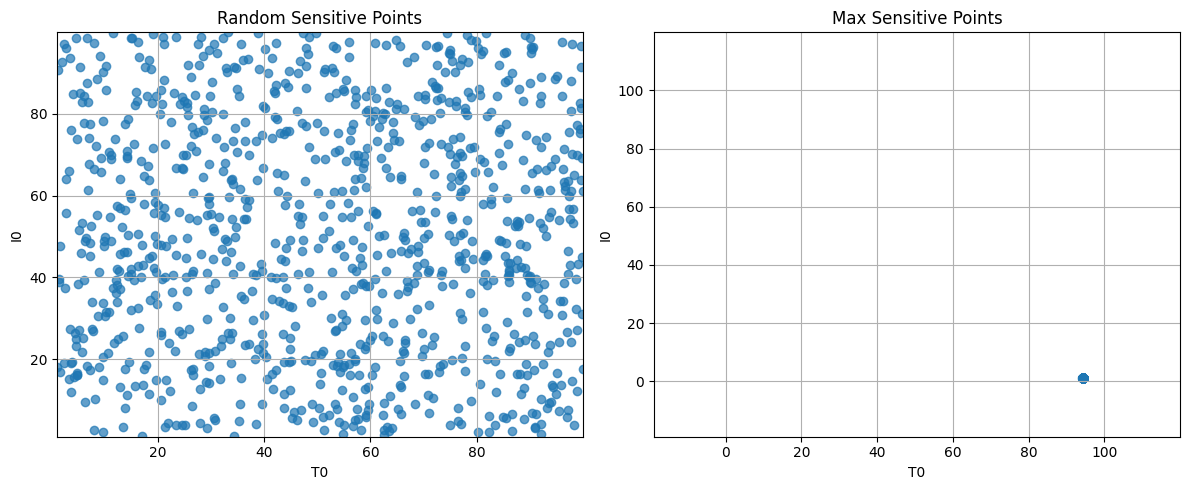

In [45]:

import matplotlib.pyplot as plt

# ---------------------------------------
# Side-by-side comparison
# ---------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Common axis limits
xmin = min(min_data["T0"].min(), max_data["T0"].min())
xmax = max(min_data["T0"].max(), max_data["T0"].max())

ymin = min(min_data["I0"].min(), max_data["I0"].min())
ymax = max(min_data["I0"].max(), max_data["I0"].max())

# ---------------------------------------
# Min-sensitive points
# ---------------------------------------

ax[0].scatter(
    min_data["T0"],
    min_data["I0"],
    alpha=0.7
)

ax[0].set_title(name_output + " Sensitive Points")
ax[0].set_xlabel("T0")
ax[0].set_ylabel("I0")
ax[0].set_xlim(xmin, xmax)
ax[0].set_ylim(ymin, ymax)
ax[0].grid(True)

# ---------------------------------------
# Max-sensitive points
# ---------------------------------------

ax[1].scatter(
    max_data["T0"],
    max_data["I0"],
    alpha=0.7
)

ax[1].set_title("Max Sensitive Points")
ax[1].set_xlabel("T0")
ax[1].set_ylabel("I0")
ax[1].set_xlim(xmin-20, xmax+20)
ax[1].set_ylim(ymin-20, ymax+20)
ax[1].grid(True)

plt.tight_layout()
plt.show()


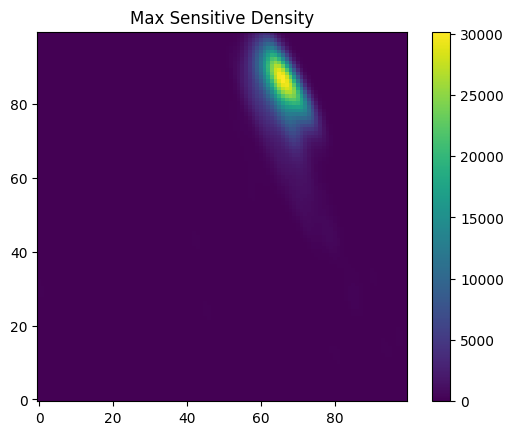

In [48]:

x = max_data["T0"]
y = max_data["I0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_max = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_max,
    origin="lower"
)

plt.colorbar()
plt.title("Max Sensitive Density")
plt.show()


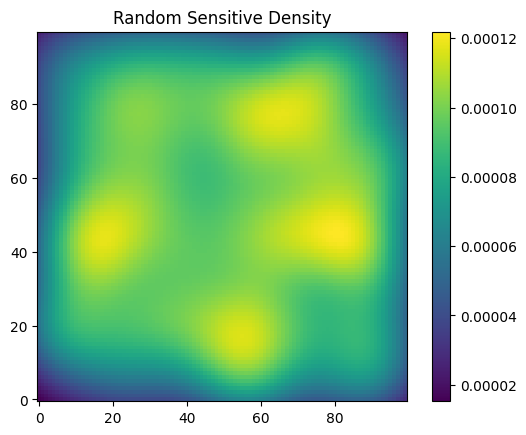

In [49]:

x = min_data["T0"]
y = min_data["I0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_min = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_min,
    origin="lower"
)

plt.colorbar()
plt.title( name_output + " Sensitive Density")
plt.show()


In [50]:

np.vstack([x,y])


array([[85.98442268, 44.7218031 , 65.12264851, ..., 17.37141693,
        87.88014414, 32.76061159],
       [22.07926048, 33.00466302, 35.80658423, ..., 64.71273346,
        24.1996039 , 44.07798026]])

In [51]:

rho_diff = rho_max - rho_min


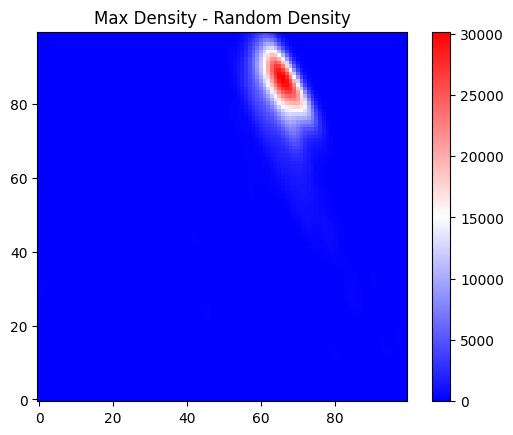

In [52]:

plt.imshow(
    rho_diff,
    origin="lower",
    cmap="bwr"
)

plt.colorbar()
plt.title("Max Density - " + name_output + " Density")
plt.show()



## Generate case 3 - Random data


In [ ]:

# ==================================================
# RANDOM BASELINE - TUMOR IMMUNE CYTOKINE MODEL
# ==================================================

import pandas as pd
import numpy as np

N = 1000

random_T = np.random.uniform(
    1.0,
    100.0,
    N
)

random_I = np.random.uniform(
    1.0,
    100.0,
    N
)

random_C = np.random.uniform(
    1.0,
    100.0,
    N
)

random_df = pd.DataFrame({
    "Time_steps": 300,
    "T0"        : random_T,
    "I0"        : random_I,
    "C0"        : random_C
})

random_df.to_csv(
    "random_points.csv",
    index=False
)

print(random_df.head())

print()
print("Saved:")
print("random_points.csv")
print("Number of points:", len(random_df))

